# Análisis del Efecto del Aumento del Parque Vehicular Liviano y el Deterioro de la Calidad del Aire con PM2.5 en la Ciudad Capital, Guatemala (2022–2025)

**Metodología:** CRISP-DM (Cross-Industry Standard Process for Data Mining)
**Enfoque:** Series de tiempo univariadas con regresores exógenos (ARIMAX / SARIMAX)
**Variable objetivo (endógena):** Concentración mensual de PM2.5 (μg/m³)

---

Este notebook está organizado estrictamente en las **6 fases de CRISP-DM**:

1. *Business Understanding* — objetivo, hipótesis y métricas de éxito.
2. *Data Understanding* — carga, EDA y visualización cruda.
3. *Data Preparation* — alineación temporal mensual, consolidación y estacionariedad.
4. *Modeling* — ARIMAX y SARIMAX.
5. *Evaluation* — AIC/BIC, RMSE/MAE y diagnóstico de residuales.
6. *Deployment* — interpretación técnica de coeficientes y conclusión estadística.


## Configuración del entorno

Importamos las librerías y fijamos parámetros de reproducibilidad y estilo. Si `pmdarima` no está instalado, las celdas que lo usan tienen un *fallback* manual basado en ACF/PACF y búsqueda en malla (grid search).

```bash
pip install pandas numpy matplotlib seaborn statsmodels scikit-learn pmdarima
```


In [114]:
# -*- coding: utf-8 -*-
# =============================================================================
# Configuración global del entorno de análisis
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

#from sklearn.metrics import mean_squared_error, mean_absolute_error
# Métricas sin sklearn (evita el bloqueo de Application Control)
def mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return np.mean((y_true - y_pred) ** 2)



def mean_absolute_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return np.mean(np.abs(y_true - y_pred))

# pmdarima es opcional: se usa para auto_arima si está disponible.
try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except Exception:
    HAS_PMDARIMA = False
    print("pmdarima no disponible: se usará grid search / ACF-PACF manual.")

# Reproducibilidad y estética
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

# Rutas de los datasets (ajustar según ubicación local)
PATH_VEHICULAR = "./Data/Vehiculos/PARQUE-VEHICULAR-2007-2025-FULL.csv"
PATH_PM25      = "./Data/PM25/PM25_DAIRY_FULL_2022_2025.csv"
PATH_CLIMA     = "./Data/Test/CLIMA_2022_2025.csv"

# Rango temporal de estudio (intersección de los tres datasets)
FECHA_INICIO = "2022-03-01"   # PM2.5 inicia en marzo 2022
FECHA_FIN    = "2025-12-31"


---
# Fase 1 · Business Understanding

## 1.1 Objetivo del proyecto
Determinar y cuantificar la **relación estadística** entre el crecimiento del parque vehicular liviano y la concentración de material particulado fino (PM2.5) en la Ciudad de Guatemala durante 2022–2025, **controlando por variables climatológicas** (temperatura, precipitación, viento y humedad) que se sabe modulan la dispersión y acumulación de contaminantes.

## 1.2 Hipótesis de investigación
- **H₀:** El crecimiento del parque vehicular liviano **no** tiene un efecto estadísticamente significativo sobre los niveles de PM2.5 (coeficiente exógeno ≈ 0, p ≥ 0.05).
- **H₁:** El crecimiento del parque vehicular liviano **sí** tiene un efecto positivo y significativo sobre PM2.5 (coeficiente > 0, p < 0.05).

## 1.3 Enfoque estadístico
Se utiliza un marco de **series de tiempo con regresores exógenos**:
- **ARIMAX** — captura la dinámica autorregresiva y de media móvil de PM2.5 más el efecto del parque vehicular.
- **SARIMAX** — añade componente **estacional anual (s=12)** y el conjunto completo de covariables climatológicas, apropiado porque la calidad del aire en Guatemala presenta un patrón estacional marcado (época seca vs. lluviosa).

## 1.4 Métricas de éxito
| Métrica | Uso |
|---|---|
| **AIC / BIC** | Selección de modelo (penalizan complejidad). Menor es mejor. |
| **RMSE / MAE** | Calidad del ajuste/predicción en μg/m³. |
| **p-valor del coeficiente exógeno** | Criterio central de la hipótesis. |
| **Ljung-Box, Jarque-Bera, Breusch-Pagan** | Validez de supuestos sobre los residuales. |

## 1.5 Limitaciones reconocidas
Con ~46 observaciones mensuales (mar-2022 a dic-2025) el tamaño muestral es modesto para series de tiempo. Esto exige **modelos parsimoniosos** y cautela al interpretar parámetros estacionales; se prioriza inferencia sobre los coeficientes exógenos por encima de la predicción de largo plazo.


---
# Fase 2 · Data Understanding

Cargamos los tres datasets, inspeccionamos tipos, nulos y distribuciones, y graficamos las series en estado **crudo** antes de cualquier transformación.


In [115]:
# =============================================================================
# 2.1 Carga de datasets
# =============================================================================
def cargar_csv(path, **kwargs):
    #\"\"\"Carga robusta de CSV con manejo de encoding latino frecuente en datos GT.\"\"\"
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except (UnicodeDecodeError, LookupError):
            continue
    # Último intento sin especificar encoding
    return pd.read_csv(path, **kwargs)

df_veh   = cargar_csv(PATH_VEHICULAR)
df_pm25  = cargar_csv(PATH_PM25)
df_clima = cargar_csv(PATH_CLIMA)

print("Parque vehicular :", df_veh.shape)
print("PM2.5            :", df_pm25.shape)
print("Clima            :", df_clima.shape)


Parque vehicular : (557454, 8)
PM2.5            : (1380, 4)
Clima            : (2891, 6)


In [116]:
# =============================================================================
# 2.2 Inspección de estructura y tipos
# =============================================================================
for nombre, df in [("PARQUE VEHICULAR", df_veh), ("PM2.5", df_pm25), ("CLIMA", df_clima)]:
    print("=" * 70)
    print(nombre)
    print("=" * 70)
    df.info()
    print("\nPrimeras filas:")
    display(df.head())
    print()


PARQUE VEHICULAR
<class 'pandas.DataFrame'>
RangeIndex: 557454 entries, 0 to 557453
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   ANIO_ALZA        557454 non-null  int64
 1   MES              557454 non-null  int64
 2   MODELO_VEHICULO  557454 non-null  str  
 3   LINEA_VEHICULO   557434 non-null  str  
 4   TIPO_VEHICULO    557454 non-null  str  
 5   USO_VEHICULO     557454 non-null  str  
 6   MARCA_VEHICULO   557454 non-null  str  
 7   CANTIDAD         557454 non-null  int64
dtypes: int64(3), str(5)
memory usage: 34.0 MB

Primeras filas:


,ANIO_ALZA,MES,MODELO_VEHICULO,LINEA_VEHICULO,TIPO_VEHICULO,USO_VEHICULO,MARCA_VEHICULO,CANTIDAD
0,2007,5,2003,SANTA FE V6 4X2,CAMIONETA,PARTICULAR,HYUNDAI,1
1,2007,5,2001,SWIFT,AUTOMOVIL,PARTICULAR,SUZUKI,1
2,2007,5,1995,METRO LSI,AUTOMOVIL,PARTICULAR,GEO,1
3,2007,5,2003,JETTA,AUTOMOVIL,PARTICULAR,VOLKSWAGEN,1
4,2007,5,2007,5,CAMIONETA,PARTICULAR,MAZDA,5



PM2.5
<class 'pandas.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    1380 non-null   int64  
 1   MONTH   1380 non-null   int64  
 2   DAY     1380 non-null   int64  
 3   PM25    1380 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 43.3 KB

Primeras filas:


,YEAR,MONTH,DAY,PM25
0,2022,3,4,4.6
1,2022,3,7,42.0
2,2022,3,8,55.0
3,2022,3,9,24.3
4,2022,3,10,73.7



CLIMA
<class 'pandas.DataFrame'>
RangeIndex: 2891 entries, 0 to 2890
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FECHA              2891 non-null   str    
 1   NOMBRE_ESTACIÓN    2891 non-null   str    
 2   TEMPERATURA_MEDIA  2891 non-null   float64
 3   PRECIPITACIÓN      2890 non-null   float64
 4   VELOCIDAD_VIENTO   2891 non-null   float64
 5   HUMEDAD_RELATIVA   2891 non-null   int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 135.6 KB

Primeras filas:


,FECHA,NOMBRE_ESTACIÓN,TEMPERATURA_MEDIA,PRECIPITACIÓN,VELOCIDAD_VIENTO,HUMEDAD_RELATIVA
0,2022-01-01,INSIVUMEH,20.3,0.0,8.6,76
1,2022-01-02,INSIVUMEH,20.2,0.0,10.0,77
2,2022-01-03,INSIVUMEH,19.1,0.0,24.7,78
3,2022-01-04,INSIVUMEH,17.5,0.5,29.7,73
4,2022-01-05,INSIVUMEH,19.0,0.0,18.7,65


In [117]:
# =============================================================================
# 2.3 Diagnóstico de valores nulos
# =============================================================================
def reporte_nulos(df, nombre):
    nulos = df.isna().sum()
    pct = (nulos / len(df) * 100).round(2)
    rep = pd.DataFrame({"n_nulos": nulos, "pct_nulos": pct})
    rep = rep[rep["n_nulos"] > 0]
    print(f"--- Nulos en {nombre} ---")
    print(rep if not rep.empty else "Sin valores nulos.")
    print()

reporte_nulos(df_veh, "Parque vehicular")
reporte_nulos(df_pm25, "PM2.5")
reporte_nulos(df_clima, "Clima")


--- Nulos en Parque vehicular ---
                n_nulos  pct_nulos
LINEA_VEHICULO       20        0.0

--- Nulos en PM2.5 ---
Sin valores nulos.

--- Nulos en Clima ---
               n_nulos  pct_nulos
PRECIPITACIÓN        1       0.03



In [118]:
# =============================================================================
# 2.4 Estadística descriptiva de las variables numéricas clave
# =============================================================================
print("Resumen CANTIDAD (parque vehicular):")
display(df_veh["CANTIDAD"].describe())

print("\nResumen PM2.5 diario:")
display(df_pm25["PM25"].describe())

print("\nResumen variables climáticas:")
display(df_clima.describe())


Resumen CANTIDAD (parque vehicular):


count    557454.000000
mean          2.751420
std          14.343186
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        1889.000000
Name: CANTIDAD, dtype: float64


Resumen PM2.5 diario:


count    1380.000000
mean       30.432826
std        42.241077
min         0.800000
25%         9.100000
50%        18.150000
75%        37.125000
max      1016.000000
Name: PM25, dtype: float64


Resumen variables climáticas:


,TEMPERATURA_MEDIA,PRECIPITACIÓN,VELOCIDAD_VIENTO,HUMEDAD_RELATIVA
count,2891.000000,2890.000000,2891.000000,2891.000000
mean,20.835766,3.509654,12.335178,72.988239
std,1.708461,9.384234,8.772397,8.471683
min,14.000000,0.000000,0.000000,43.000000
25%,19.800000,0.000000,4.700000,67.000000
50%,20.900000,0.000000,11.000000,73.000000
75%,22.000000,1.300000,18.500000,79.000000
max,25.700000,86.300000,60.700000,108.000000


In [119]:
# =============================================================================
# 2.5 Construcción de índices temporales para visualización cruda
#     (sin todavía hacer la consolidación final; solo para graficar)
# =============================================================================

# --- PM2.5: construir fecha diaria a partir de YEAR/MONTH/DAY ---
pm25_raw = df_pm25.copy()
pm25_raw["FECHA"] = pd.to_datetime(
    dict(year=pm25_raw["YEAR"], month=pm25_raw["MONTH"], day=pm25_raw["DAY"]),
    errors="coerce"
)
pm25_raw = pm25_raw.dropna(subset=["FECHA"]).sort_values("FECHA")

# --- Clima: parsear FECHA ---
clima_raw = df_clima.copy()
clima_raw["FECHA"] = pd.to_datetime(clima_raw["FECHA"], errors="coerce", dayfirst=True)
clima_raw = clima_raw.dropna(subset=["FECHA"]).sort_values("FECHA")

# --- Parque vehicular: fecha mensual a partir de ANIO_ALZA/MES ---
veh_raw = df_veh.copy()
veh_mensual_raw = (
    veh_raw.groupby(["ANIO_ALZA", "MES"], as_index=False)["CANTIDAD"].sum()
)
veh_mensual_raw["FECHA"] = pd.to_datetime(
    dict(year=veh_mensual_raw["ANIO_ALZA"], month=veh_mensual_raw["MES"], day=1),
    errors="coerce"
)
veh_mensual_raw = veh_mensual_raw.dropna(subset=["FECHA"]).sort_values("FECHA")

print("Rango PM2.5 :", pm25_raw['FECHA'].min().date(), "→", pm25_raw['FECHA'].max().date())
print("Rango Clima :", clima_raw['FECHA'].min().date(), "→", clima_raw['FECHA'].max().date())
print("Rango Veh.  :", veh_mensual_raw['FECHA'].min().date(), "→", veh_mensual_raw['FECHA'].max().date())


Rango PM2.5 : 2022-03-04 → 2025-12-31
Rango Clima : 2022-01-01 → 2025-12-12
Rango Veh.  : 1980-01-01 → 2025-12-01


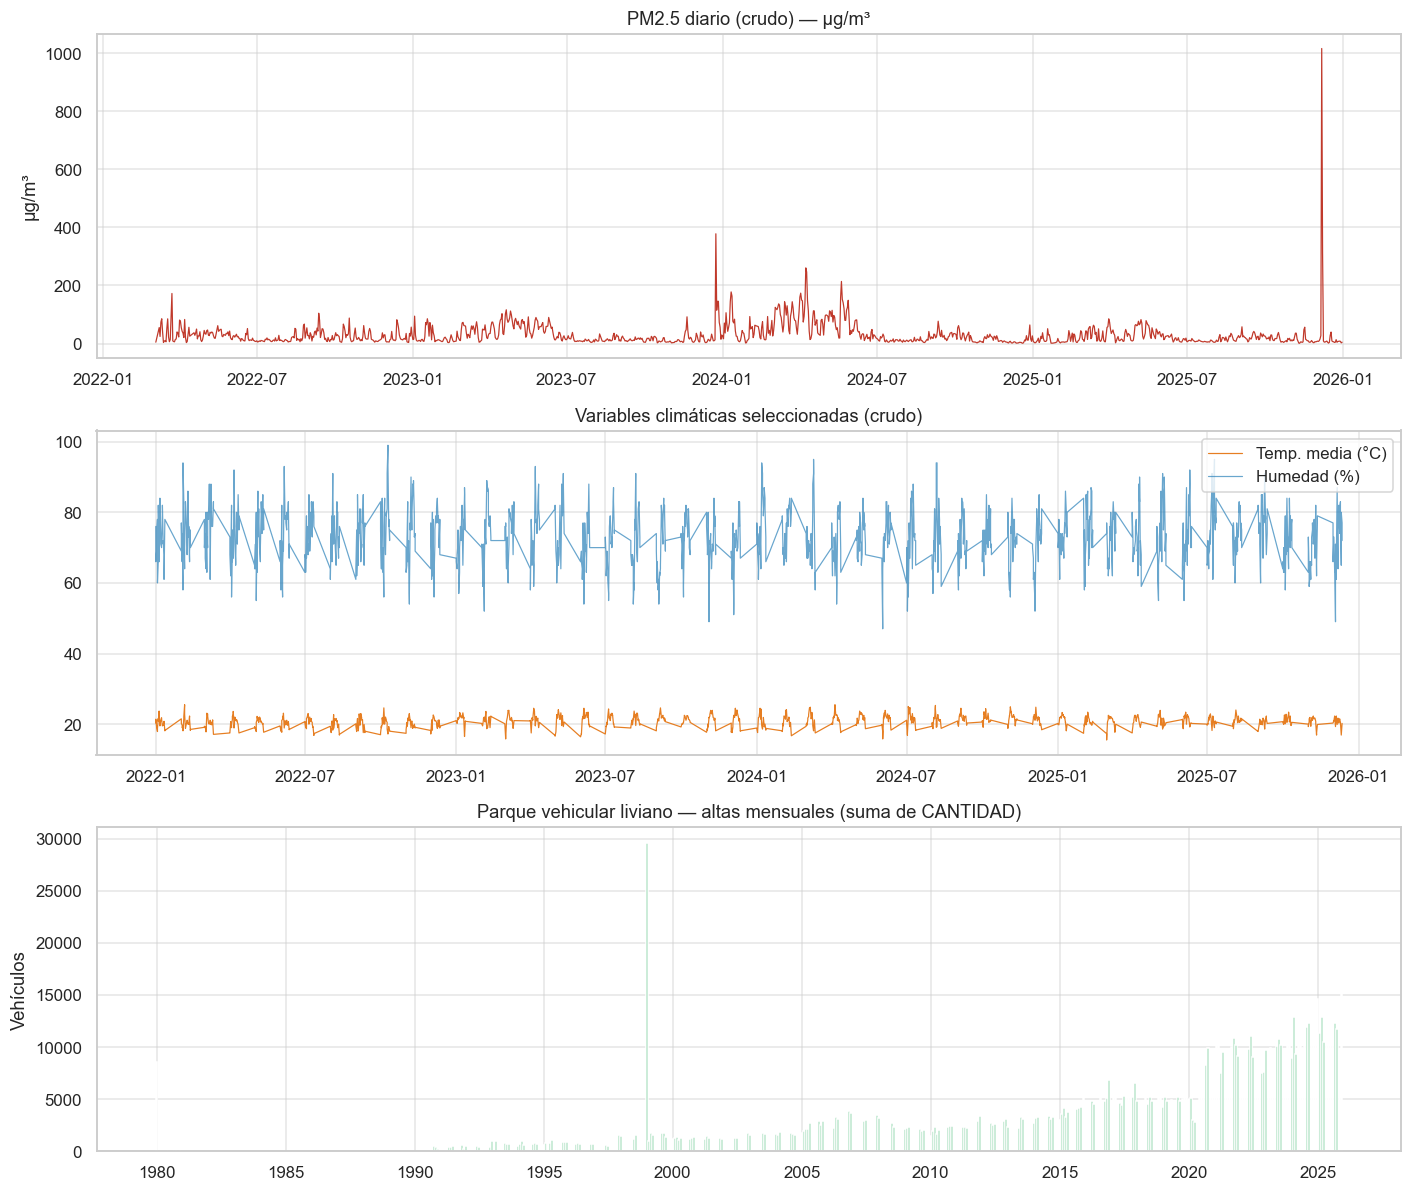

In [120]:
# =============================================================================
# 2.6 Visualización de las series en estado CRUDO
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

axes[0].plot(pm25_raw["FECHA"], pm25_raw["PM25"], color="#c0392b", lw=0.8)
axes[0].set_title("PM2.5 diario (crudo) — μg/m³")
axes[0].set_ylabel("μg/m³")

axes[1].plot(clima_raw["FECHA"], clima_raw["TEMPERATURA_MEDIA"], color="#e67e22", lw=0.8, label="Temp. media (°C)")
axes[1].plot(clima_raw["FECHA"], clima_raw["HUMEDAD_RELATIVA"], color="#2980b9", lw=0.8, alpha=0.7, label="Humedad (%)")
axes[1].set_title("Variables climáticas seleccionadas (crudo)")
axes[1].legend(loc="upper right")

axes[2].bar(veh_mensual_raw["FECHA"], veh_mensual_raw["CANTIDAD"], width=20, color="#27ae60")
axes[2].set_title("Parque vehicular liviano — altas mensuales (suma de CANTIDAD)")
axes[2].set_ylabel("Vehículos")

plt.tight_layout()
plt.show()


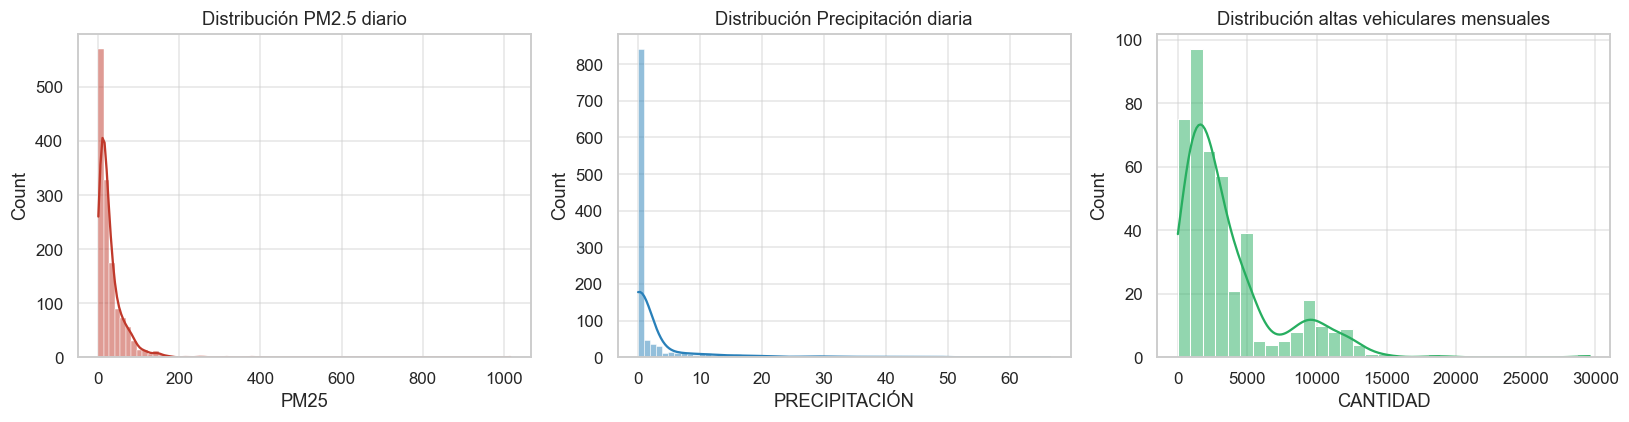

In [121]:
# =============================================================================
# 2.7 Distribuciones de las variables principales
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(pm25_raw["PM25"], kde=True, ax=axes[0], color="#c0392b")
axes[0].set_title("Distribución PM2.5 diario")

sns.histplot(clima_raw["PRECIPITACIÓN"], kde=True, ax=axes[1], color="#2980b9")
axes[1].set_title("Distribución Precipitación diaria")

sns.histplot(veh_mensual_raw["CANTIDAD"], kde=True, ax=axes[2], color="#27ae60")
axes[2].set_title("Distribución altas vehiculares mensuales")
plt.tight_layout()
plt.show()


---
# Fase 3 · Data Preparation

Esta es la fase **crítica**: se debe llevar todo a una **granularidad mensual común** y construir un único `DataFrame` con `DatetimeIndex` mensual. Reglas de agregación:

- **Parque vehicular:** suma de `CANTIDAD` por (`ANIO_ALZA`, `MES`). Representa las **altas mensuales** (flujo). También derivaremos el **acumulado** (parque instalado, *stock*) que es conceptualmente la variable de presión sobre la calidad del aire.
- **PM2.5:** **promedio** mensual de la concentración diaria.
- **Temperatura, humedad, viento:** **promedio** mensual.
- **Precipitación:** **suma** mensual (lámina acumulada) — métrica estándar; también conservamos el promedio diario como referencia.


In [122]:
# =============================================================================
# 3.1 Agregación mensual de cada fuente
# =============================================================================

# --- PM2.5: promedio mensual ---
pm25_m = (
    pm25_raw.set_index("FECHA")["PM25"]
    .resample("MS")          # MS = Month Start
    .mean()
    .rename("PM25")
)

# --- Clima: agregaciones diferenciadas por variable ---
clima_idx = clima_raw.set_index("FECHA")
clima_m = pd.DataFrame({
    "TEMPERATURA_MEDIA": clima_idx["TEMPERATURA_MEDIA"].resample("MS").mean(),
    "HUMEDAD_RELATIVA":  clima_idx["HUMEDAD_RELATIVA"].resample("MS").mean(),
    "VELOCIDAD_VIENTO":  clima_idx["VELOCIDAD_VIENTO"].resample("MS").mean(),
    "PRECIPITACION":     clima_idx["PRECIPITACIÓN"].resample("MS").sum(),   # suma mensual
})

# --- Parque vehicular: ya está mensual; lo indexamos a MS ---
veh_m = (
    veh_mensual_raw.set_index("FECHA")["CANTIDAD"]
    .resample("MS").sum()
    .rename("VEH_ALTAS")            # flujo: altas del mes
)

print("PM2.5 mensual:", pm25_m.shape)
print("Clima mensual:", clima_m.shape)
print("Veh.  mensual:", veh_m.shape)


PM2.5 mensual: (46,)
Clima mensual: (48, 4)
Veh.  mensual: (552,)


In [123]:
# =============================================================================
# 3.2 Filtrado temporal al rango común y consolidación
# =============================================================================
# Recortamos el parque vehicular (que cubre 2007-2025) al rango de estudio.
veh_m   = veh_m.loc[FECHA_INICIO:FECHA_FIN]
pm25_m  = pm25_m.loc[FECHA_INICIO:FECHA_FIN]
clima_m = clima_m.loc[FECHA_INICIO:FECHA_FIN]

# Unión por índice mensual (inner join => intersección exacta de fechas)
df = pd.concat([pm25_m, veh_m, clima_m], axis=1, join="inner").sort_index()

# Variable de STOCK (parque acumulado) = altas acumuladas dentro del periodo.
# Si dispones del parque base a inicio de 2022, súmalo aquí como offset.
df["VEH_ACUMULADO"] = df["VEH_ALTAS"].cumsum()

# Aseguramos frecuencia mensual explícita en el índice (clave para statsmodels)
df = df.asfreq("MS")

print("DataFrame consolidado:", df.shape)
display(df.head())
display(df.tail())


DataFrame consolidado: (46, 7)


,PM25,VEH_ALTAS,TEMPERATURA_MEDIA,HUMEDAD_RELATIVA,VELOCIDAD_VIENTO,PRECIPITACION,VEH_ACUMULADO
FECHA,,,,,,,
2022-03-01,36.219231,9418,20.178261,75.652174,14.313043,43.2,9418
2022-04-01,34.653846,9124,20.291304,73.347826,16.143478,33.2,18542
2022-05-01,35.042857,9811,20.178261,73.913043,15.165217,26.0,28353
2022-06-01,18.170000,11113,20.117391,74.000000,12.634783,35.3,39466
2022-07-01,11.100000,9099,20.439130,74.434783,12.543478,106.2,48565


,PM25,VEH_ALTAS,TEMPERATURA_MEDIA,HUMEDAD_RELATIVA,VELOCIDAD_VIENTO,PRECIPITACION,VEH_ACUMULADO
FECHA,,,,,,,
2025-08-01,15.629032,12756,21.200000,73.250000,13.108333,27.4,442183
2025-09-01,24.186667,12323,20.320833,77.041667,10.916667,105.1,454506
2025-10-01,15.880645,11775,21.204167,71.875000,12.554167,46.6,466281
2025-11-01,12.773333,9590,20.662500,70.333333,13.116667,39.9,475871
2025-12-01,51.590323,18661,20.508333,72.916667,12.158333,92.9,494532


In [124]:
# =============================================================================
# 3.3 Tratamiento de nulos residuales tras la unión
#     (meses sin medición se interpolan temporalmente)
# =============================================================================
print("Nulos por columna tras la unión:")
print(df.isna().sum(), "\n")

# Interpolación temporal lineal + relleno de extremos (parsimonioso dado n pequeño)
df = df.interpolate(method="time").bfill().ffill()

print("Nulos tras interpolación:", df.isna().sum().sum())
print("Número de observaciones mensuales:", len(df))


Nulos por columna tras la unión:
PM25                 0
VEH_ALTAS            0
TEMPERATURA_MEDIA    0
HUMEDAD_RELATIVA     0
VELOCIDAD_VIENTO     0
PRECIPITACION        0
VEH_ACUMULADO        0
dtype: int64 

Nulos tras interpolación: 0
Número de observaciones mensuales: 46


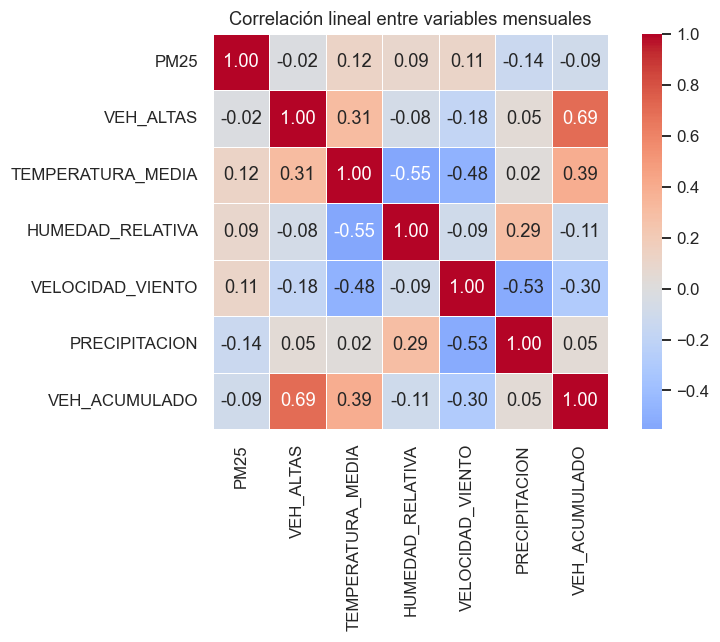

In [125]:
# =============================================================================
# 3.4 Matriz de correlación exploratoria
# =============================================================================
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5)
plt.title("Correlación lineal entre variables mensuales")
plt.tight_layout()
plt.show()


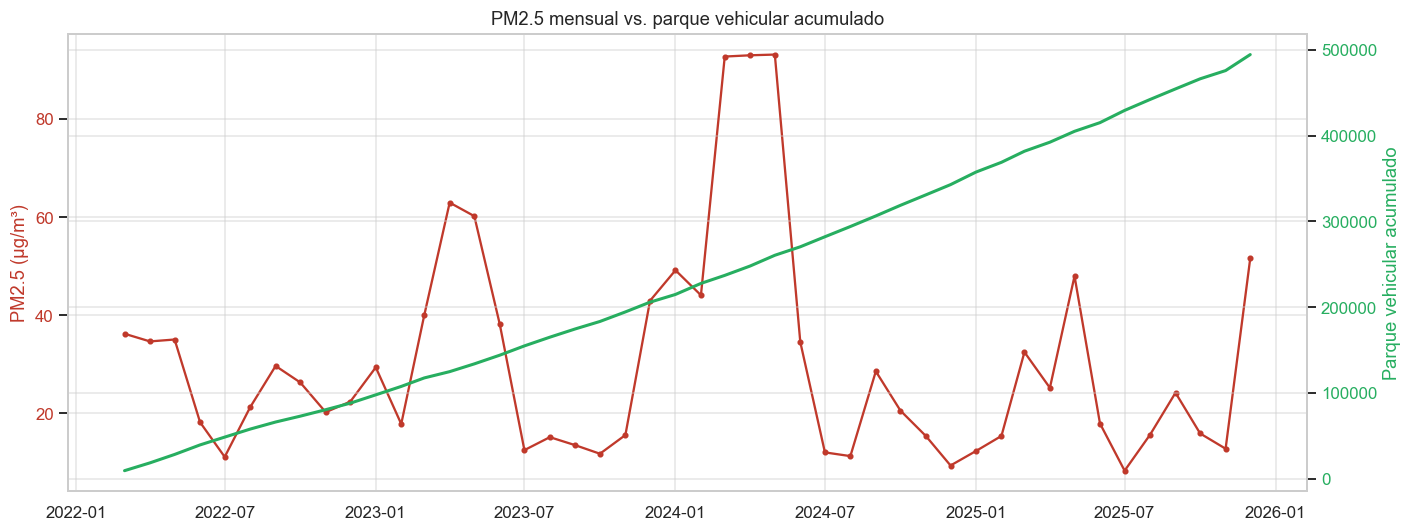

In [126]:
# =============================================================================
# 3.5 Serie consolidada de PM2.5 con su exógena principal
# =============================================================================
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(df.index, df["PM25"], color="#c0392b", marker="o", ms=3, label="PM2.5 (μg/m³)")
ax1.set_ylabel("PM2.5 (μg/m³)", color="#c0392b")
ax1.tick_params(axis="y", labelcolor="#c0392b")

ax2 = ax1.twinx()
ax2.plot(df.index, df["VEH_ACUMULADO"], color="#27ae60", lw=2, label="Parque acumulado")
ax2.set_ylabel("Parque vehicular acumulado", color="#27ae60")
ax2.tick_params(axis="y", labelcolor="#27ae60")

plt.title("PM2.5 mensual vs. parque vehicular acumulado")
fig.tight_layout()
plt.show()


## 3.6 Pruebas de estacionariedad (ADF)

La estacionariedad es requisito para los componentes ARMA. Aplicamos la **prueba de Dickey-Fuller Aumentada (ADF)**:

- **H₀:** la serie tiene raíz unitaria (es **no** estacionaria).
- Si **p < 0.05** → rechazamos H₀ → la serie es estacionaria.

Complementamos con **KPSS** (hipótesis invertida) para una decisión más robusta y determinamos el orden de diferenciación `d`.


In [127]:
# =============================================================================
# 3.6 Funciones de prueba de estacionariedad
# =============================================================================
def test_adf(serie, nombre=""):
    #\"\"\"Dickey-Fuller Aumentada. p<0.05 => estacionaria.\"\"\"
    serie = serie.dropna()
    stat, p, lags, nobs, crit, _ = adfuller(serie, autolag="AIC")
    veredicto = "ESTACIONARIA" if p < 0.05 else "NO estacionaria"
    print(f"[ADF] {nombre:18s} | estad={stat:7.3f} | p={p:6.4f} | {veredicto}")
    return p

def test_kpss(serie, nombre=""):
    #\"\"\"KPSS. p<0.05 => NO estacionaria (H0 = estacionaria).\"\"\"
    serie = serie.dropna()
    stat, p, lags, crit = kpss(serie, regression="c", nlags="auto")
    veredicto = "NO estacionaria" if p < 0.05 else "ESTACIONARIA"
    print(f"[KPSS]{nombre:18s} | estad={stat:7.3f} | p={p:6.4f} | {veredicto}")
    return p

print("=== Series en nivel ===")
for col in ["PM25", "VEH_ACUMULADO", "VEH_ALTAS", "TEMPERATURA_MEDIA"]:
    test_adf(df[col], col)
print()
for col in ["PM25", "VEH_ACUMULADO"]:
    test_kpss(df[col], col)


=== Series en nivel ===
[ADF] PM25               | estad= -3.474 | p=0.0087 | ESTACIONARIA
[ADF] VEH_ACUMULADO      | estad=  5.283 | p=1.0000 | NO estacionaria
[ADF] VEH_ALTAS          | estad= -0.079 | p=0.9515 | NO estacionaria
[ADF] TEMPERATURA_MEDIA  | estad= -1.927 | p=0.3196 | NO estacionaria

[KPSS]PM25               | estad=  0.095 | p=0.1000 | ESTACIONARIA
[KPSS]VEH_ACUMULADO      | estad=  1.025 | p=0.0100 | NO estacionaria


In [128]:
# =============================================================================
# 3.7 Determinación del orden de diferenciación 'd' para PM2.5
# =============================================================================
def orden_diferenciacion(serie, max_d=2, alpha=0.05):
    #\"\"\"Devuelve el menor d tal que la serie diferenciada es estacionaria por ADF.\"\"\"
    s = serie.dropna().copy()
    for d in range(max_d + 1):
        p = adfuller(s, autolag="AIC")[1]
        if p < alpha:
            return d
        s = s.diff().dropna()
    return max_d

d_pm25 = orden_diferenciacion(df["PM25"])
print(f"Orden de diferenciación sugerido para PM2.5: d = {d_pm25}")

# Visualizar PM2.5 diferenciada (si d>=1)
if d_pm25 >= 1:
    pm25_diff = df["PM25"].diff().dropna()
    test_adf(pm25_diff, "PM2.5 diff(1)")
    plt.figure(figsize=(13, 4))
    plt.plot(pm25_diff.index, pm25_diff.values, color="#8e44ad", marker="o", ms=3)
    plt.axhline(0, color="k", lw=.8)
    plt.title("PM2.5 — primera diferencia")
    plt.tight_layout(); plt.show()


Orden de diferenciación sugerido para PM2.5: d = 0


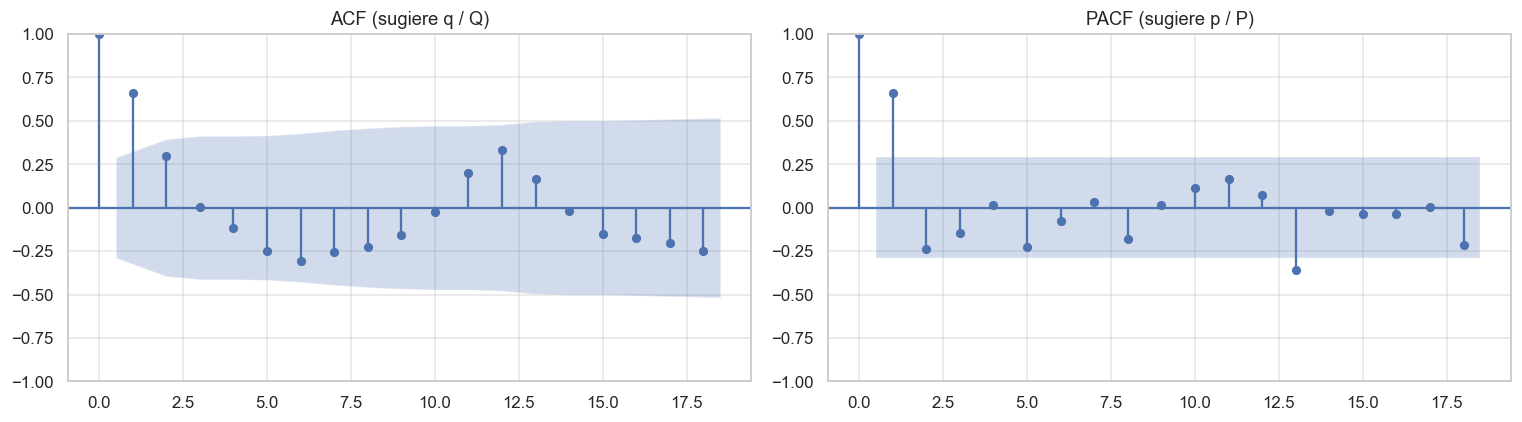

In [129]:
# =============================================================================
# 3.8 ACF y PACF para guiar la selección de (p, q)
# =============================================================================
serie_acf = df["PM25"].diff(d_pm25).dropna() if d_pm25 >= 1 else df["PM25"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_acf, lags=min(18, len(serie_acf)//2 - 1), ax=axes[0])
axes[0].set_title("ACF (sugiere q / Q)")
plot_pacf(serie_acf, lags=min(18, len(serie_acf)//2 - 1), ax=axes[1], method="ywm")
axes[1].set_title("PACF (sugiere p / P)")
plt.tight_layout(); plt.show()


## 3.9 Separación train / test y matriz exógena

Reservamos los **últimos 6 meses** como conjunto de prueba (*hold-out*) para evaluar capacidad predictiva fuera de muestra. Definimos dos conjuntos de exógenas:

- **Exógena ARIMAX:** sólo el parque vehicular (`VEH_ACUMULADO`).
- **Exógenas SARIMAX:** parque vehicular + clima completo.

Las exógenas se **estandarizan** (z-score con estadísticos de *train*) para que sus coeficientes sean comparables y el optimizador converja mejor.


In [130]:
# =============================================================================
# 3.9 Split temporal y estandarización de exógenas
# =============================================================================
H_TEST = 6                               # meses de hold-out
y = df["PM25"].astype(float)

EXOG_ARIMAX  = ["VEH_ACUMULADO"]
EXOG_SARIMAX = ["VEH_ACUMULADO", "TEMPERATURA_MEDIA", "PRECIPITACION",
                "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]

y_train, y_test = y.iloc[:-H_TEST], y.iloc[-H_TEST:]

def estandarizar(train_df, test_df):
    #\"\"\"z-score usando media/std del TRAIN para no filtrar información.\"\"\"
    mu, sd = train_df.mean(), train_df.std(ddof=0).replace(0, 1)
    return (train_df - mu) / sd, (test_df - mu) / sd

X1_tr, X1_te = estandarizar(df[EXOG_ARIMAX].iloc[:-H_TEST],  df[EXOG_ARIMAX].iloc[-H_TEST:])
X2_tr, X2_te = estandarizar(df[EXOG_SARIMAX].iloc[:-H_TEST], df[EXOG_SARIMAX].iloc[-H_TEST:])

print(f"Train: {len(y_train)} meses | Test: {len(y_test)} meses")
print("Exógenas ARIMAX :", EXOG_ARIMAX)
print("Exógenas SARIMAX:", EXOG_SARIMAX)


Train: 40 meses | Test: 6 meses
Exógenas ARIMAX : ['VEH_ACUMULADO']
Exógenas SARIMAX: ['VEH_ACUMULADO', 'TEMPERATURA_MEDIA', 'PRECIPITACION', 'VELOCIDAD_VIENTO', 'HUMEDAD_RELATIVA']


---
# Fase 4 · Modeling

Construimos los dos modelos sobre el conjunto de entrenamiento. En ambos la **endógena es PM2.5**.


## 4.1 Modelo 1 — ARIMAX

`PM2.5 ~ ARIMA(p,d,q)` con regresor exógeno **parque vehicular acumulado**. Buscamos `(p,d,q)` óptimos minimizando AIC. Si `pmdarima` está disponible usamos `auto_arima`; si no, una búsqueda en malla acotada.


In [131]:
# =============================================================================
# 4.1 Selección de (p,d,q) para ARIMAX
# =============================================================================
def grid_search_arima(y, exog, d, p_range=range(0,4), q_range=range(0,4),
                      seasonal_order=(0,0,0,0)):
    #\"\"\"Búsqueda en malla minimizando AIC. Fallback sin pmdarima.\"\"\"
    mejor = {"aic": np.inf, "order": None, "res": None}
    for p in p_range:
        for q in q_range:
            try:
                res = SARIMAX(y, exog=exog, order=(p, d, q),
                              seasonal_order=seasonal_order,
                              enforce_stationarity=False,
                              enforce_invertibility=False).fit(disp=False)
                if res.aic < mejor["aic"]:
                    mejor = {"aic": res.aic, "order": (p, d, q), "res": res}
            except Exception:
                continue
    return mejor

if HAS_PMDARIMA:
    auto1 = pm.auto_arima(
        y_train, exogenous=X1_tr, d=d_pm25, seasonal=False,
        stepwise=True, suppress_warnings=True, error_action="ignore",
        max_p=4, max_q=4, information_criterion="aic"
    )
    order_arimax = auto1.order
    print("auto_arima → order ARIMAX:", order_arimax)
else:
    best1 = grid_search_arima(y_train, X1_tr, d_pm25)
    order_arimax = best1["order"]
    print("grid search → order ARIMAX:", order_arimax)


auto_arima → order ARIMAX: (0, 0, 2)


In [132]:
# =============================================================================
# 4.1b Ajuste final del ARIMAX y resumen
# =============================================================================
arimax = SARIMAX(
    y_train, exog=X1_tr, order=order_arimax,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

print(arimax.summary())


                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                   40
Model:               SARIMAX(0, 0, 2)   Log Likelihood                -163.010
Date:                Thu, 11 Jun 2026   AIC                            334.020
Time:                        00:10:24   BIC                            340.463
Sample:                    03-01-2022   HQIC                           336.291
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
VEH_ACUMULADO     2.7551     10.278      0.268      0.789     -17.389      22.899
ma.L1             1.0631      0.179      5.943      0.000       0.712       1.414
ma.L2             0.6696      0.228     

## 4.2 Modelo 2 — SARIMAX

`PM2.5 ~ SARIMA(p,d,q)(P,D,Q,12)` con **parque vehicular + clima**. La estacionalidad anual `s=12` modela el ciclo seca/lluvia. Buscamos los órdenes regular y estacional.


In [133]:
# =============================================================================
# 4.2 Selección de órdenes para SARIMAX (regular + estacional, s=12)
# =============================================================================
S = 12

if HAS_PMDARIMA:
    auto2 = pm.auto_arima(
        y_train, exogenous=X2_tr, d=d_pm25, seasonal=True, m=S,
        D=None, stepwise=True, suppress_warnings=True, error_action="ignore",
        max_p=3, max_q=3, max_P=2, max_Q=2, information_criterion="aic"
    )
    order_sarimax     = auto2.order
    seasonal_sarimax  = auto2.seasonal_order
    print("auto_arima → order:", order_sarimax, "| seasonal:", seasonal_sarimax)
else:
    # Grid acotado por el n pequeño: probamos combinaciones estacionales simples.
    mejor = {"aic": np.inf, "order": None, "seasonal": None, "res": None}
    for P in (0, 1):
        for Q in (0, 1):
            for D in (0, 1):
                b = grid_search_arima(y_train, X2_tr, d_pm25,
                                      p_range=range(0,3), q_range=range(0,3),
                                      seasonal_order=(P, D, Q, S))
                if b["res"] is not None and b["aic"] < mejor["aic"]:
                    mejor = {"aic": b["aic"], "order": b["order"],
                             "seasonal": (P, D, Q, S), "res": b["res"]}
    order_sarimax    = mejor["order"]
    seasonal_sarimax = mejor["seasonal"]
    print("grid search → order:", order_sarimax, "| seasonal:", seasonal_sarimax)


auto_arima → order: (2, 0, 0) | seasonal: (1, 0, 0, 12)


In [134]:
# =============================================================================
# 4.2b Ajuste final del SARIMAX y resumen
# =============================================================================
sarimax = SARIMAX(
    y_train, exog=X2_tr, order=order_sarimax,
    seasonal_order=seasonal_sarimax,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

print(sarimax.summary())


                                     SARIMAX Results                                      
Dep. Variable:                               PM25   No. Observations:                   40
Model:             SARIMAX(2, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -103.647
Date:                            Thu, 11 Jun 2026   AIC                            225.295
Time:                                    00:10:29   BIC                            236.618
Sample:                                03-01-2022   HQIC                           228.556
                                     - 06-01-2025                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
VEH_ACUMULADO        -0.5897     18.212     -0.032      0.974     -36.285      35.105
TEMPERATURA_ME

---
# Fase 5 · Evaluation

Comparamos los modelos por **AIC/BIC** (ajuste penalizado) y por **RMSE/MAE** en el *hold-out*, luego diagnosticamos los residuales del modelo ganador.


In [135]:
# =============================================================================
# 5.1 Comparación AIC / BIC
# =============================================================================
comp = pd.DataFrame({
    "Modelo": ["ARIMAX", "SARIMAX"],
    "Orden":  [str(order_arimax), f"{order_sarimax}x{seasonal_sarimax}"],
    "AIC":    [arimax.aic, sarimax.aic],
    "BIC":    [arimax.bic, sarimax.bic],
    "LogLik": [arimax.llf, sarimax.llf],
}).set_index("Modelo")
display(comp.round(2))


,Orden,AIC,BIC,LogLik
Modelo,,,,
ARIMAX,"(0, 0, 2)",334.02,340.46,-163.01
SARIMAX,"(2, 0, 0)x(1, 0, 0, 12)",225.29,236.62,-103.65


In [136]:
# =============================================================================
# 5.2 Pronóstico sobre el hold-out y métricas RMSE / MAE
# =============================================================================
def evaluar_forecast(modelo, X_test, y_test, nombre):
    fc = modelo.get_forecast(steps=len(y_test), exog=X_test)
    y_hat = fc.predicted_mean
    rmse = np.sqrt(mean_squared_error(y_test, y_hat))
    mae  = mean_absolute_error(y_test, y_hat)
    print(f"{nombre:9s} | RMSE={rmse:6.3f} | MAE={mae:6.3f}")
    return y_hat, rmse, mae

yhat1, rmse1, mae1 = evaluar_forecast(arimax,  X1_te, y_test, "ARIMAX")
yhat2, rmse2, mae2 = evaluar_forecast(sarimax, X2_te, y_test, "SARIMAX")

# Selección del modelo ganador (criterio combinado: menor RMSE de test, desempate por AIC)
if rmse2 <= rmse1:
    ganador, yhat_g, nombre_g = sarimax, yhat2, "SARIMAX"
else:
    ganador, yhat_g, nombre_g = arimax, yhat1, "ARIMAX"
print("\nModelo ganador:", nombre_g)


ARIMAX    | RMSE=22.814 | MAE=18.023
SARIMAX   | RMSE=21.654 | MAE=15.436

Modelo ganador: SARIMAX


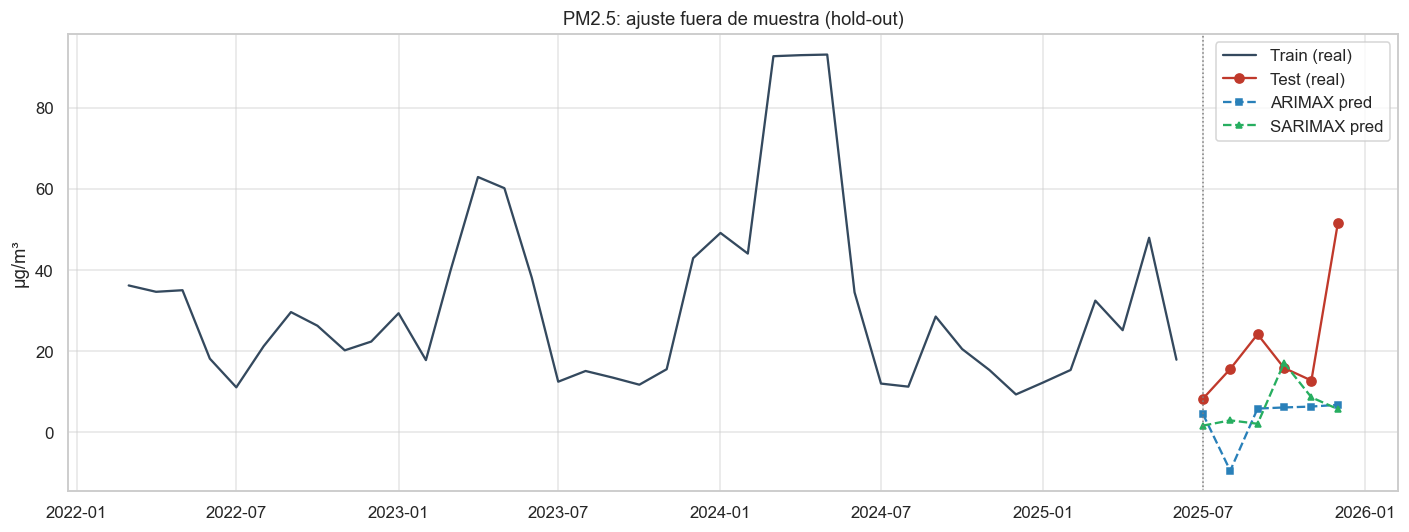

In [137]:
# =============================================================================
# 5.3 Visualización ajuste vs. realidad en el hold-out
# =============================================================================
plt.figure(figsize=(13, 5))
plt.plot(y_train.index, y_train, color="#34495e", label="Train (real)")
plt.plot(y_test.index, y_test, color="#c0392b", marker="o", label="Test (real)")
plt.plot(y_test.index, yhat1, "--", color="#2980b9", marker="s", ms=4, label="ARIMAX pred")
plt.plot(y_test.index, yhat2, "--", color="#27ae60", marker="^", ms=4, label="SARIMAX pred")
plt.axvline(y_test.index[0], color="gray", ls=":", lw=1)
plt.title("PM2.5: ajuste fuera de muestra (hold-out)")
plt.ylabel("μg/m³"); plt.legend()
plt.tight_layout(); plt.show()


In [138]:
# =============================================================================
# 5.4 Diagnóstico de residuales del modelo ganador
# =============================================================================
resid = ganador.resid.dropna()

# --- Ljung-Box: H0 = no autocorrelación en residuales ---
lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
print("--- Ljung-Box (H0: residuales NO autocorrelacionados) ---")
display(lb)

# --- Jarque-Bera: H0 = normalidad ---
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
print(f"\n--- Jarque-Bera --- estad={jb_stat:.3f} | p={jb_p:.4f} | "
      f"skew={skew:.3f} | kurtosis={kurt:.3f}")
print("Residuales normales." if jb_p > 0.05 else "Se rechaza normalidad (p<0.05).")

# --- Breusch-Pagan: H0 = homocedasticidad (residuales vs. tiempo) ---
exog_bp = np.column_stack([np.ones(len(resid)), np.arange(len(resid))])
bp_stat, bp_p, _, _ = het_breuschpagan(resid, exog_bp)
print(f"\n--- Breusch-Pagan --- estad={bp_stat:.3f} | p={bp_p:.4f}")
print("Homocedástico." if bp_p > 0.05 else "Indicio de heterocedasticidad (p<0.05).")


--- Ljung-Box (H0: residuales NO autocorrelacionados) ---


,lb_stat,lb_pvalue
6,3.749886,0.71048
12,7.519825,0.82144



--- Jarque-Bera --- estad=9.268 | p=0.0097 | skew=1.077 | kurtosis=3.961
Se rechaza normalidad (p<0.05).

--- Breusch-Pagan --- estad=2.425 | p=0.1194
Homocedástico.


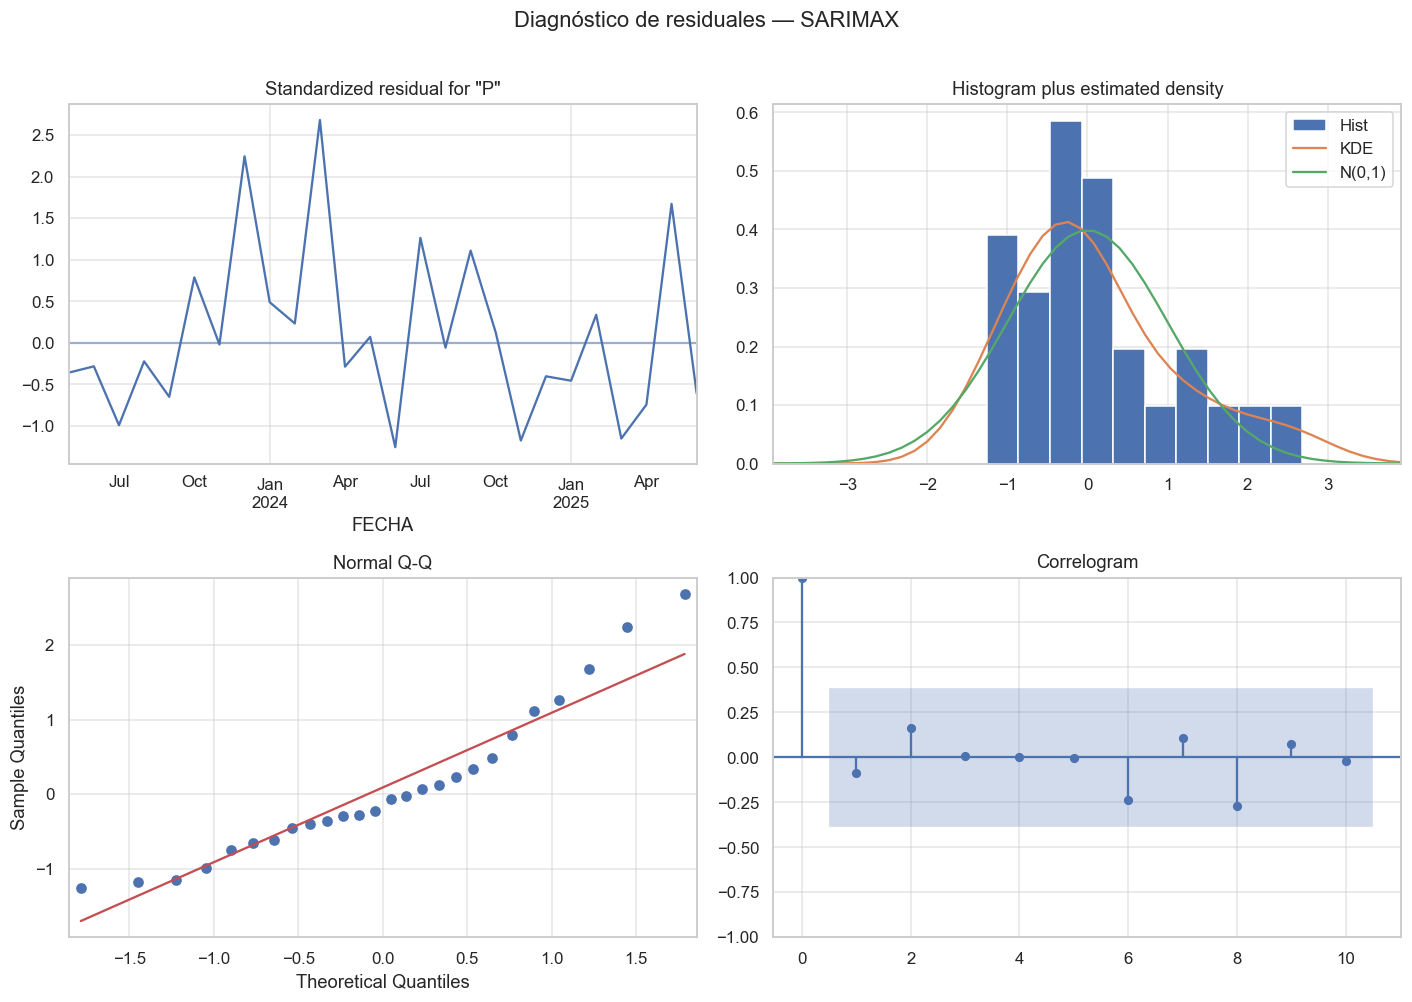

In [139]:
# =============================================================================
# 5.5 Gráficos de diagnóstico estándar de statsmodels
# =============================================================================
ganador.plot_diagnostics(figsize=(13, 9))
plt.suptitle(f"Diagnóstico de residuales — {nombre_g}", y=1.01)
plt.tight_layout(); plt.show()


---
# Fase 6 · Deployment

En esta fase final no desplegamos un servicio en producción, sino que **traducimos los resultados estadísticos a conclusiones de investigación**: ¿existe evidencia de que el parque vehicular incide en el PM2.5, una vez controlado el clima?


In [140]:
# =============================================================================
# 6.1 Extracción e interpretación de coeficientes exógenos
# =============================================================================
def tabla_coeficientes(modelo, exog_names, nombre):
    #\"\"\"Construye tabla de coeficientes exógenos con p-valor y significancia.\"\"\"
    params  = modelo.params
    pvalues = modelo.pvalues
    conf    = modelo.conf_int()
    filas = []
    for v in exog_names:
        if v in params.index:
            p = pvalues[v]
            sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"
            filas.append({
                "Variable": v,
                "Coef": round(params[v], 4),
                "p-valor": round(p, 4),
                "IC95%_inf": round(conf.loc[v, 0], 4),
                "IC95%_sup": round(conf.loc[v, 1], 4),
                "Signif.": sig,
            })
    print(f"=== Coeficientes exógenos — {nombre} ===")
    return pd.DataFrame(filas).set_index("Variable")

tab_arimax  = tabla_coeficientes(arimax,  EXOG_ARIMAX,  "ARIMAX")
display(tab_arimax)
tab_sarimax = tabla_coeficientes(sarimax, EXOG_SARIMAX, "SARIMAX")
display(tab_sarimax)
print("Códigos: *** p<0.01 | ** p<0.05 | * p<0.10 | ns = no significativo")


=== Coeficientes exógenos — ARIMAX ===


,Coef,p-valor,IC95%_inf,IC95%_sup,Signif.
Variable,,,,,
VEH_ACUMULADO,2.7551,0.7886,-17.3891,22.8994,ns


=== Coeficientes exógenos — SARIMAX ===


,Coef,p-valor,IC95%_inf,IC95%_sup,Signif.
Variable,,,,,
VEH_ACUMULADO,-0.5897,0.9742,-36.2846,35.1052,ns
TEMPERATURA_MEDIA,0.4849,0.9384,-11.8183,12.7882,ns
PRECIPITACION,-2.7950,0.1824,-6.9029,1.3130,ns
VELOCIDAD_VIENTO,-9.3551,0.0993,-20.4801,1.7698,*
HUMEDAD_RELATIVA,-4.4512,0.3822,-14.4351,5.5327,ns


Códigos: *** p<0.01 | ** p<0.05 | * p<0.10 | ns = no significativo


In [141]:
# =============================================================================
# 6.2 Conclusión automatizada sobre la hipótesis de investigación
# =============================================================================
tab_g = tab_sarimax if nombre_g == "SARIMAX" else tab_arimax
veh_row = tab_g.loc["VEH_ACUMULADO"]
coef, pval = veh_row["Coef"], veh_row["p-valor"]

print("="*72)
print("CONCLUSIÓN ESTADÍSTICA — efecto del parque vehicular sobre PM2.5")
print("="*72)
print(f"Modelo ganador      : {nombre_g}")
print(f"Coeficiente VEH     : {coef}  (sobre exógena estandarizada)")
print(f"p-valor             : {pval}")
print("-"*72)
if pval < 0.05:
    signo = "positiva" if coef > 0 else "negativa"
    print(f"Se RECHAZA H0 (p<0.05): existe una relación {signo} y estadísticamente")
    print("significativa entre el crecimiento del parque vehicular liviano y PM2.5.")
    print(f"Interpretación: a mayor parque vehicular acumulado, el PM2.5 mensual")
    print(f"{'aumenta' if coef>0 else 'disminuye'} de forma significativa, controlando por clima.")
else:
    print("NO se rechaza H0 (p>=0.05): con estos datos NO hay evidencia suficiente")
    print("de un efecto significativo del parque vehicular sobre PM2.5. Posibles causas:")
    print("- Tamaño muestral reducido (~46 meses) que limita la potencia estadística.")
    print("- Colinealidad con variables climáticas o estacionalidad que absorbe el efecto.")
    print("- El stock vehicular varía suavemente y aporta poca variación dentro del periodo.")


CONCLUSIÓN ESTADÍSTICA — efecto del parque vehicular sobre PM2.5
Modelo ganador      : SARIMAX
Coeficiente VEH     : -0.5897  (sobre exógena estandarizada)
p-valor             : 0.9742
------------------------------------------------------------------------
NO se rechaza H0 (p>=0.05): con estos datos NO hay evidencia suficiente
de un efecto significativo del parque vehicular sobre PM2.5. Posibles causas:
- Tamaño muestral reducido (~46 meses) que limita la potencia estadística.
- Colinealidad con variables climáticas o estacionalidad que absorbe el efecto.
- El stock vehicular varía suavemente y aporta poca variación dentro del periodo.


## 6.3 Lectura técnica de resultados

**Cómo interpretar la salida anterior**

1. **Signo y magnitud del coeficiente de `VEH_ACUMULADO`.** Como la exógena está estandarizada (z-score), el coeficiente expresa el cambio esperado en PM2.5 (μg/m³) ante **una desviación estándar** de aumento en el parque acumulado. Un signo positivo es coherente con la hipótesis de que más vehículos → más emisiones → mayor PM2.5.

2. **p-valor.** Es el criterio central de la investigación. Con p < 0.05 se concluye relación significativa; entre 0.05 y 0.10 hay evidencia marginal que conviene reportar con cautela.

3. **Variables climáticas (SARIMAX).** Esperables: `PRECIPITACION` y `VELOCIDAD_VIENTO` con coeficiente **negativo** (lavan y dispersan el particulado), `TEMPERATURA_MEDIA` y `HUMEDAD_RELATIVA` con efectos según la dinámica local de inversión térmica. Su inclusión **aísla** el efecto vehicular del efecto meteorológico — esto es lo que da validez causal-observacional al coeficiente vehicular.

4. **Validez del modelo (Fase 5).** La conclusión sobre el coeficiente sólo es confiable si los residuales pasan **Ljung-Box** (sin autocorrelación), son aproximadamente normales (Jarque-Bera) y homocedásticos (Breusch-Pagan). Si fallan, los errores estándar — y por tanto los p-valores — pueden estar sesgados; en ese caso conviene errores robustos (`cov_type="robust"`) o reespecificar el modelo.

## 6.4 Recomendaciones para la tesis
- Reportar **AIC/BIC y RMSE/MAE** de ambos modelos en una tabla comparativa (Fase 5.1–5.2).
- Acompañar la conclusión con los **intervalos de confianza** del coeficiente vehicular, no sólo el p-valor.
- Dado el `n` reducido, considerar como robustez: (a) usar `VEH_ALTAS` (flujo) en lugar del acumulado, (b) modelar PM2.5 en logaritmo, (c) validación con *rolling forecast* en lugar de un único hold-out.
- Documentar explícitamente que se trata de evidencia **asociacional** sobre datos observacionales, no de un experimento causal.

## 6.5 Persistencia del modelo (opcional)
```python
ganador.save("modelo_pm25_ganador.pkl")
# Recarga:  from statsmodels.tsa.statespace.sarimax import SARIMAXResults
#           modelo = SARIMAXResults.load("modelo_pm25_ganador.pkl")
```
